<a href="https://colab.research.google.com/github/logonzalezsa/PPAE/blob/main/02_Cuadernos/PPAE_06_Resultante_Sistema_Fuerzas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROGRAMACIÓN PARA ANÁLISIS DE ESTRUCTURAS

**Universidad Nacional de Colombia – Sede Palmira**  
**Programa Curricular de Ingeniería Agrícola**

### Tema
**Sistemas de fuerzas**

### Taller
**Aplicaciones de programación en Estática**

### Ejercicio
**Fuerza resultante y punto de aplicación de un sistema de fuerzas paralelas**

**Elaborado por:**  
Luis Octavio González Salcedo  
Profesor Titular

## 1. Contexto y objetivo

Un sistema de fuerzas paralelas puede sustituirse por una **fuerza resultante equivalente**, siempre que esta produzca sobre el cuerpo el mismo efecto externo que el sistema original.

Para un conjunto de $n$ fuerzas verticales paralelas $F_i$, la magnitud de la fuerza resultante se obtiene mediante:

$$
R=\sum_{i=1}^{n}F_i
$$

La posición de la resultante se determina aplicando el **principio de equivalencia de momentos** respecto a un punto de referencia:

$$
R X_C=\sum_{i=1}^{n}F_iX_i
$$

de donde:

$$
\boxed{
X_C=\frac{\sum_{i=1}^{n}F_iX_i}{\sum_{i=1}^{n}F_i}
}
$$

donde:

- $F_i$ es la magnitud de cada fuerza;
- $X_i$ es la posición de cada fuerza medida desde un origen de referencia;
- $R$ es la fuerza resultante;
- $X_C$ es la posición de aplicación de la resultante.

El objetivo de este cuaderno es desarrollar un algoritmo general que permita ingresar un número variable de fuerzas, calcular su resultante y determinar su punto de aplicación.

Finalmente, el sistema de fuerzas y su resultante serán representados gráficamente para facilitar la interpretación y verificación de los resultados.

### 1.1 Convención de signos y casos posibles

Para representar fuerzas verticales que pueden actuar en sentidos opuestos, se adoptará la siguiente convención de signos:

$$
F_i>0 \quad \Rightarrow \quad \text{fuerza vertical hacia arriba}
$$

$$
F_i<0 \quad \Rightarrow \quad \text{fuerza vertical hacia abajo}
$$

La posición $X_i$ de cada fuerza se medirá desde un origen de referencia ubicado sobre el eje longitudinal de la viga.

La fuerza resultante del sistema será:

$$
R=\sum_{i=1}^{n}F_i
$$

y el momento resultante respecto al origen:

$$
M_O=\sum_{i=1}^{n}F_iX_i
$$

Cuando:

$$
R\neq0
$$

el sistema puede representarse mediante una única fuerza resultante cuya posición es:

$$
X_C=\frac{M_O}{R}
$$

Si:

$$
R=0
$$

no puede determinarse la posición de una fuerza resultante mediante la expresión anterior.

En este caso pueden presentarse dos situaciones:

- Si $R=0$ y $M_O\neq0$, el sistema es equivalente a un **par o momento resultante**.
- Si $R=0$ y $M_O=0$, el sistema de fuerzas se encuentra en **equilibrio**.

Esta verificación permitirá que el algoritmo identifique automáticamente el tipo de sistema obtenido.

## 2. Organización matricial del sistema de fuerzas

Un sistema formado por $n$ fuerzas verticales puede organizarse mediante una matriz:

$$
[C]=
\begin{bmatrix}
i & F_i & X_i & F_iX_i
\end{bmatrix}_{n\times4}
$$

donde cada fila representa una fuerza del sistema.

Las columnas contienen:

- $i$: identificación de la fuerza;
- $F_i$: magnitud y sentido de la fuerza;
- $X_i$: posición de la fuerza respecto al origen;
- $F_iX_i$: momento de la fuerza respecto al origen.

El usuario ingresará únicamente los valores $F_i$ y $X_i$. La identificación y el producto $F_iX_i$ serán generados automáticamente por el programa.

In [ ]:
# ============================================================
# DEFINICIÓN DE LA MATRIZ DEL SISTEMA DE FUERZAS
# ============================================================

import numpy as np

# Número de fuerzas del sistema
n = int(input("Ingrese el número de fuerzas del sistema: "))

# Matriz del sistema:
# columnas -> i, Fi, Xi, Fi*Xi
C = np.zeros((n, 4), dtype=float)

# Identificación automática de las fuerzas
C[:, 0] = np.arange(1, n + 1)

print(f"\nEl sistema tendrá {n} fuerzas.")

print("\nMATRIZ DEL SISTEMA [C]")
print("----------------------")
print(C)

print("\nDimensiones de [C]:", C.shape)

Ingrese el número de fuerzas del sistema: 4

El sistema tendrá 4 fuerzas.

MATRIZ DEL SISTEMA [C]
----------------------
[[1. 0. 0. 0.]
 [2. 0. 0. 0.]
 [3. 0. 0. 0.]
 [4. 0. 0. 0.]]

Dimensiones de [C]: (4, 4)


### 2.1 Ingreso de las fuerzas y sus posiciones

Para cada fuerza del sistema se ingresarán únicamente dos valores:

$$
F_i \qquad X_i
$$

donde $F_i$ representa la magnitud y el sentido de la fuerza, mientras que $X_i$ corresponde a su posición respecto al origen de referencia.

De acuerdo con la convención adoptada:

$$
F_i>0 \rightarrow \text{fuerza hacia arriba}
$$

$$
F_i<0 \rightarrow \text{fuerza hacia abajo}
$$

El programa calculará automáticamente el momento de cada fuerza respecto al origen:

$$
M_i=F_iX_i
$$

Después del ingreso de cada fuerza se mostrará la matriz actualizada, permitiendo verificar los datos suministrados.

In [ ]:
# ============================================================
# INGRESO DE LAS FUERZAS Y SUS POSICIONES
# ============================================================

for i in range(n):

    print("\n" + "=" * 55)
    print(f"FUERZA {i + 1}")
    print("=" * 55)

    print("\nIngrese los datos en el siguiente orden:")
    print("Fi   Xi")

    while True:

        entrada = input("\nIngrese Fi y Xi separados por un espacio: ")

        try:
            datos = [float(x) for x in entrada.split()]

            if len(datos) == 2:
                break
            else:
                print(
                    f"\nDebe ingresar exactamente 2 valores. "
                    f"Se ingresaron {len(datos)}."
                )

        except ValueError:
            print("\nLos datos deben ser valores numéricos.")

    Fi, Xi = datos

    # Almacenar fuerza y posición
    C[i, 1] = Fi
    C[i, 2] = Xi

    # Momento de la fuerza respecto al origen
    C[i, 3] = Fi * Xi

    print("\nMATRIZ DEL SISTEMA [C] ACTUALIZADA")
    print("----------------------------------")
    print(C)


FUERZA 1

Ingrese los datos en el siguiente orden:
Fi   Xi

Ingrese Fi y Xi separados por un espacio: -400 0

MATRIZ DEL SISTEMA [C] ACTUALIZADA
----------------------------------
[[   1. -400.    0.   -0.]
 [   2.    0.    0.    0.]
 [   3.    0.    0.    0.]
 [   4.    0.    0.    0.]]

FUERZA 2

Ingrese los datos en el siguiente orden:
Fi   Xi

Ingrese Fi y Xi separados por un espacio: -200 3

MATRIZ DEL SISTEMA [C] ACTUALIZADA
----------------------------------
[[   1. -400.    0.   -0.]
 [   2. -200.    3. -600.]
 [   3.    0.    0.    0.]
 [   4.    0.    0.    0.]]

FUERZA 3

Ingrese los datos en el siguiente orden:
Fi   Xi

Ingrese Fi y Xi separados por un espacio: -100 7

MATRIZ DEL SISTEMA [C] ACTUALIZADA
----------------------------------
[[   1. -400.    0.   -0.]
 [   2. -200.    3. -600.]
 [   3. -100.    7. -700.]
 [   4.    0.    0.    0.]]

FUERZA 4

Ingrese los datos en el siguiente orden:
Fi   Xi

Ingrese Fi y Xi separados por un espacio: -100 9

MATRIZ DEL SISTEMA 

## 3. Determinación de la resultante y su punto de aplicación

Una vez construido el sistema de fuerzas, la fuerza resultante se determina mediante:

$$
R=\sum_{i=1}^{n}F_i
$$

y el momento resultante respecto al origen:

$$
M_O=\sum_{i=1}^{n}F_iX_i
$$

Si $R\neq0$, la posición de aplicación de la fuerza resultante se obtiene imponiendo equivalencia de momentos:

$$
R X_C=M_O
$$

por tanto:

$$
\boxed{X_C=\frac{M_O}{R}}
$$

El signo de $R$ indica el sentido de la fuerza resultante de acuerdo con la convención establecida.

El algoritmo también verificará los casos especiales en los cuales $R=0$, distinguiendo entre un sistema equivalente a un par y un sistema en equilibrio.

In [ ]:
# ============================================================
# RESULTANTE DEL SISTEMA DE FUERZAS
# ============================================================

# Sumatoria de fuerzas
R = np.sum(C[:, 1])

# Sumatoria de momentos respecto al origen
Mo = np.sum(C[:, 3])

# Tolerancia numérica
tol = 1e-10

print("RESULTADOS DEL SISTEMA")
print("======================")
print(f"Resultante R = {R:.4f}")
print(f"Momento respecto al origen Mo = {Mo:.4f}")

# ------------------------------------------------------------
# CLASIFICACIÓN DEL SISTEMA
# ------------------------------------------------------------

if abs(R) > tol:

    Xc = Mo / R

    print("\nEl sistema es equivalente a una FUERZA RESULTANTE.")
    print(f"Punto de aplicación Xc = {Xc:.4f}")

    if R > 0:
        print("Sentido de la resultante: hacia arriba ↑")
    else:
        print("Sentido de la resultante: hacia abajo ↓")

elif abs(Mo) > tol:

    Xc = None

    print("\nLa fuerza resultante es nula.")
    print("El sistema es equivalente a un PAR RESULTANTE.")
    print(f"Momento del par = {Mo:.4f}")

else:

    Xc = None

    print("\nLa fuerza resultante y el momento resultante son nulos.")
    print("El sistema se encuentra en EQUILIBRIO.")

RESULTADOS DEL SISTEMA
Resultante R = -800.0000
Momento respecto al origen Mo = -2200.0000

El sistema es equivalente a una FUERZA RESULTANTE.
Punto de aplicación Xc = 2.7500
Sentido de la resultante: hacia abajo ↓


## 4. Verificación de la equivalencia

Una fuerza resultante es equivalente al sistema original cuando produce la misma fuerza neta y el mismo momento respecto al punto de referencia.

Para el sistema original:

$$
M_O=\sum_{i=1}^{n}F_iX_i
$$

Para la fuerza resultante:

$$
M_R=R X_C
$$

Por tanto, debe cumplirse:

$$
\boxed{
\sum_{i=1}^{n}F_iX_i=RX_C
}
$$

Esta comprobación permite verificar numéricamente que la fuerza resultante calculada representa adecuadamente el efecto externo del sistema original.

In [ ]:
# ============================================================
# VERIFICACIÓN DE LA EQUIVALENCIA DE MOMENTOS
# ============================================================

if Xc is not None:

    momento_resultante = R * Xc

    print("VERIFICACIÓN DE MOMENTOS")
    print("========================")
    print(f"Momento del sistema original = {Mo:.4f}")
    print(f"Momento de la resultante     = {momento_resultante:.4f}")

    if np.isclose(Mo, momento_resultante):
        print("\n✓ Verificación correcta:")
        print("  El sistema original y la resultante son equivalentes.")
    else:
        print("\n✗ Los momentos no coinciden.")

else:
    print("No existe una fuerza resultante con punto de aplicación Xc.")

VERIFICACIÓN DE MOMENTOS
Momento del sistema original = -2200.0000
Momento de la resultante     = -2200.0000

✓ Verificación correcta:
  El sistema original y la resultante son equivalentes.


## 5. Representación gráfica del sistema de fuerzas

La representación gráfica permite comparar el sistema original de fuerzas con su sistema equivalente.

En la parte superior se representarán las fuerzas $F_i$ aplicadas en sus respectivas posiciones $X_i$.

En la parte inferior se mostrará la fuerza resultante:

$$
R=\sum_{i=1}^{n}F_i
$$

aplicada en la posición calculada:

$$
X_C=\frac{\sum F_iX_i}{\sum F_i}
$$

Aunque ambos sistemas presentan una distribución diferente de fuerzas, son estáticamente equivalentes porque poseen la misma fuerza neta y producen el mismo momento respecto al origen.

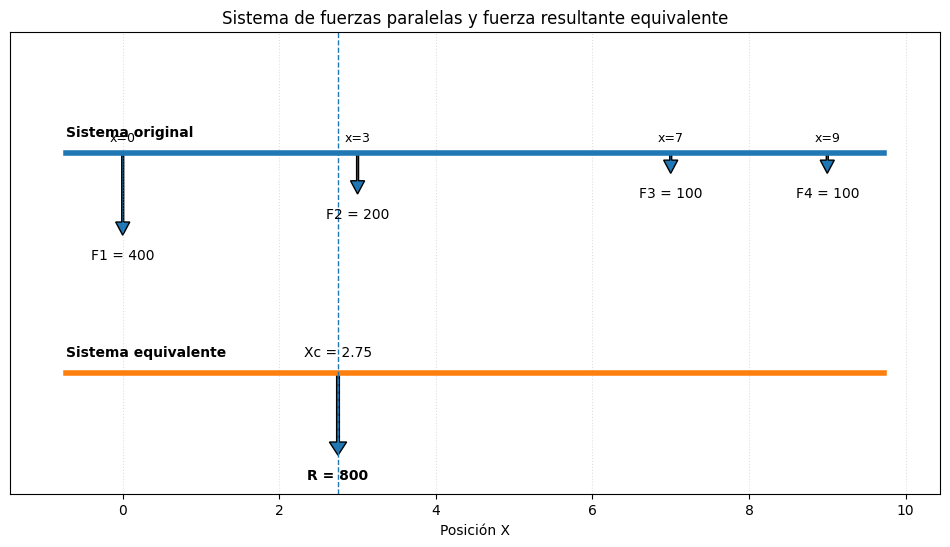

In [ ]:
# ============================================================
# REPRESENTACIÓN GRÁFICA DEL SISTEMA DE FUERZAS
# ============================================================

import matplotlib.pyplot as plt

if Xc is not None:

    fuerzas = C[:, 1]
    posiciones = C[:, 2]

    # Longitud gráfica de referencia
    xmin = min(0, np.min(posiciones), Xc)
    xmax = max(np.max(posiciones), Xc)

    margen = max((xmax - xmin) * 0.08, 0.5)

    fig, ax = plt.subplots(figsize=(12, 6))

    # --------------------------------------------------------
    # SISTEMA ORIGINAL
    # --------------------------------------------------------

    y_original = 1.0

    # Viga
    ax.plot(
        [xmin - margen, xmax + margen],
        [y_original, y_original],
        linewidth=4
    )

    # Escala gráfica para las flechas
    Fmax = np.max(np.abs(fuerzas))
    escala = 0.75 / Fmax

    for i in range(n):

        Fi = fuerzas[i]
        Xi = posiciones[i]

        dy = Fi * escala

        # Fuerza
        ax.arrow(
            Xi,
            y_original,
            0,
            dy,
            width=0.025,
            head_width=0.18,
            head_length=0.12,
            length_includes_head=True
        )

        # Valor de la fuerza
        desplazamiento_texto = 0.12 if Fi > 0 else -0.12

        ax.text(
            Xi,
            y_original + dy + desplazamiento_texto,
            f"F{i+1} = {abs(Fi):.0f}",
            ha="center",
            va="bottom" if Fi > 0 else "top"
        )

        # Posición
        ax.text(
            Xi,
            y_original + 0.08,
            f"x={Xi:g}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.text(
        xmin - margen,
        y_original + 0.15,
        "Sistema original",
        fontweight="bold"
    )

    # --------------------------------------------------------
    # SISTEMA EQUIVALENTE
    # --------------------------------------------------------

    y_resultante = -1.0

    # Viga equivalente
    ax.plot(
        [xmin - margen, xmax + margen],
        [y_resultante, y_resultante],
        linewidth=4
    )

    # Resultante
    escala_R = 0.75 / abs(R)
    dy_R = R * escala_R

    ax.arrow(
        Xc,
        y_resultante,
        0,
        dy_R,
        width=0.035,
        head_width=0.22,
        head_length=0.12,
        length_includes_head=True
    )

    ax.text(
        Xc,
        y_resultante + dy_R - 0.12 if R < 0
        else y_resultante + dy_R + 0.12,
        f"R = {abs(R):.0f}",
        ha="center",
        va="top" if R < 0 else "bottom",
        fontweight="bold"
    )

    # Localización de Xc
    ax.axvline(
        Xc,
        linestyle="--",
        linewidth=1
    )

    ax.text(
        Xc,
        y_resultante + 0.12,
        f"Xc = {Xc:.2f}",
        ha="center",
        va="bottom"
    )

    ax.text(
        xmin - margen,
        y_resultante + 0.15,
        "Sistema equivalente",
        fontweight="bold"
    )

    # --------------------------------------------------------
    # PRESENTACIÓN
    # --------------------------------------------------------

    ax.set_xlabel("Posición X")
    ax.set_title(
        "Sistema de fuerzas paralelas y fuerza resultante equivalente"
    )

    ax.set_xlim(xmin - 2*margen, xmax + 2*margen)
    ax.set_ylim(-2.1, 2.1)

    ax.set_yticks([])
    ax.grid(axis="x", linestyle=":", alpha=0.4)

    plt.show()

else:

    print(
        "El sistema no posee una fuerza resultante con "
        "punto de aplicación Xc."
    )

## 6. Interpretación de los posibles resultados

El algoritmo desarrollado permite analizar un sistema general de fuerzas verticales paralelas y distinguir tres situaciones.

### Caso 1. Fuerza resultante

Si:

$$
R\neq0
$$

el sistema puede sustituirse por una única fuerza resultante:

$$
R=\sum F_i
$$

aplicada en:

$$
X_C=\frac{\sum F_iX_i}{R}
$$

La fuerza resultante produce la misma fuerza neta y el mismo momento que el sistema original.

### Caso 2. Par resultante

Si:

$$
R=0
$$

pero:

$$
M_O\neq0
$$

las fuerzas se anulan entre sí, pero permanece un momento neto. El sistema es equivalente a un **par resultante** y, por tanto, no existe una posición $X_C$ para una fuerza resultante.

### Caso 3. Equilibrio

Si:

$$
R=0
$$

y:

$$
M_O=0
$$

el sistema satisface simultáneamente las condiciones:

$$
\sum F_i=0
$$

$$
\sum M_O=0
$$

y se encuentra en equilibrio.

## 7. Reflexión final

Un sistema de fuerzas paralelas puede representarse mediante un sistema equivalente que conserve tanto la fuerza neta como su efecto de momento.

En este ejercicio, la información correspondiente a las fuerzas y sus posiciones fue organizada mediante una matriz:

$$
[C]=
\begin{bmatrix}
i & F_i & X_i & F_iX_i
\end{bmatrix}
$$

A partir de ella fue posible desarrollar sistemáticamente la secuencia:

$$
\boxed{
\text{Sistema de fuerzas}
\rightarrow
[C]
\rightarrow
R
\rightarrow
M_O
\rightarrow
X_C
\rightarrow
\text{Sistema equivalente}
}
$$

El algoritmo desarrollado no depende de un número específico de fuerzas. Por tanto, puede aplicarse a diferentes sistemas de fuerzas verticales paralelas modificando únicamente los datos de entrada.

La convención de signos permite considerar fuerzas que actúan en sentidos opuestos y, adicionalmente, identificar diferentes comportamientos del sistema:

$$
R\neq0
\quad\Rightarrow\quad
\text{fuerza resultante}
$$

$$
R=0,\quad M_O\neq0
\quad\Rightarrow\quad
\text{par resultante}
$$

$$
R=0,\quad M_O=0
\quad\Rightarrow\quad
\text{equilibrio}
$$

La verificación mediante momentos permitió comprobar que la fuerza resultante calculada produce el mismo efecto externo que el sistema original, mientras que la representación gráfica facilitó la interpretación física del resultado.

De esta manera, la programación permite transformar un procedimiento convencional de Estática en un algoritmo general capaz no solamente de realizar operaciones, sino también de identificar e interpretar el sistema equivalente obtenido.

> **Programar un problema de Estática no consiste únicamente en obtener una resultante, sino en reconocer matemáticamente qué sistema equivalente representan las fuerzas originales.**